## Pycharm is worthless with widgets, so use VS Code or Jupyter Notebook for this notebook.

# Interactive wine explorer with plotly and ipywidgets

Use the widgets below to switch features and compare the wine cultivars interactively.

In [13]:
from sklearn.datasets import load_wine
import pandas as pd
import plotly.express as px
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display

# Prefer inline renderer in VS Code/Jupyter so figures appear inside widget outputs
pio.renderers.default = 'vscode' if 'vscode' in pio.renderers else 'plotly_mimetype'

# Workaround for 'web output not supported' in some IDEs
import IPython
if IPython.get_ipython():
    IPython.get_ipython().run_line_magic('matplotlib', 'inline')

wine = load_wine(as_frame=True)
df = wine.frame.copy()
df['target_name'] = df['target'].map(dict(enumerate(wine.target_names)))
feature_options = list(wine.feature_names)
size_options = ['proline', 'flavanoids', 'color_intensity', 'alcohol']
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [14]:
def scatter_features(x_axis='alcohol', y_axis='color_intensity', size='proline'):
    fig = px.scatter(
        df,
        x=x_axis,
        y=y_axis,
        color='target_name',
        size=size,
        hover_name='target_name',
        title='Wine feature explorer',
    )
    return fig

# Always show an initial chart even before widget interaction
display(scatter_features())

widgets.interact(
    scatter_features,
    x_axis=feature_options,
    y_axis=feature_options,
    size=size_options,
)

interactive(children=(Dropdown(description='x_axis', options=('alcohol', 'malic_acid', 'ash', 'alcalinity_of_a…

<function __main__.scatter_features(x_axis='alcohol', y_axis='color_intensity', size='proline')>

In [ ]:
dimension_slider = widgets.IntSlider(value=4, min=2, max=6, description='Top N')

def show_top_features(top_n):
    ranking = df.drop(columns=['target', 'target_name']).var().sort_values(ascending=False).head(top_n)
    fig = px.bar(
        x=ranking.index,
        y=ranking.values,
        labels={'x': 'Feature', 'y': 'Variance'},
        title='Highest-variance wine features',
    )
    return fig

# Always show an initial chart even before widget interaction
display(show_top_features(dimension_slider.value))

widgets.interact(show_top_features, top_n=dimension_slider)

interactive(children=(IntSlider(value=4, description='Top N', max=6, min=2), Output()), _dom_classes=('widget-…

<function __main__.show_top_features(top_n)>

In [21]:
px.parallel_coordinates(
    df,
    color='target',
    dimensions=['alcohol', 'malic_acid', 'ash', 'color_intensity', 'proline'],
    labels={'target': 'Cultivar'}
)

https://coderzcolumn.com/tutorials/data-science/interactive-charts-using-matplotlib-and-ipywidgets

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import ipywidgets as widgets

import warnings
warnings.filterwarnings("ignore")

# %matplotlib widget

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()

iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df["FlowerType"] = iris.target #[iris.target_names[t] for t in iris.target]

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),FlowerType
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [17]:
def create_scatter(feature1, feature2):
    with plt.style.context("fast"):
        fig = plt.figure(figsize=(8,4))

        plt.scatter(x = iris_df[feature1],
                    y = iris_df[feature2],
                    c=iris_df["FlowerType"],
                    s=20
                   )

        plt.xlabel(feature1.capitalize())
        plt.ylabel(feature2.capitalize())

        plt.title("%s vs %s"%(feature1.capitalize(), feature2.capitalize()))

In [18]:
widgets.interact(create_scatter, feature1=iris.feature_names, feature2=iris.feature_names);

interactive(children=(Dropdown(description='feature1', options=('sepal length (cm)', 'sepal width (cm)', 'peta…

In [6]:
@widgets.interact(feature1=iris.feature_names, feature2=iris.feature_names)
def create_scatter(feature1, feature2):
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize=(8,4))

        plt.scatter(x = iris_df[feature1],
                    y = iris_df[feature2],
                    c=iris_df["FlowerType"],
                    s=20
                   )

        plt.xlabel(feature1.capitalize())
        plt.ylabel(feature2.capitalize())

        plt.title("%s vs %s"%(feature1.capitalize(), feature2.capitalize()))

interactive(children=(Dropdown(description='feature1', options=('sepal length (cm)', 'sepal width (cm)', 'peta…

In [7]:
def create_scatter(feature1, feature2):
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize=(8,4))

        plt.scatter(x = iris_df[feature1],
                    y = iris_df[feature2],
                    c=iris_df["FlowerType"],
                    s=20
                   )

        plt.xlabel(feature1.capitalize())
        plt.ylabel(feature2.capitalize())

        plt.title("%s vs %s"%(feature1.capitalize(), feature2.capitalize()))

In [9]:
feature1_drop = widgets.Dropdown(options=iris.feature_names, value = iris.feature_names[0])
feature1_drop

Dropdown(options=('sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'), value='se…

In [10]:
feature2_drop = widgets.Dropdown(options=iris.feature_names, value = iris.feature_names[1])
feature2_drop

Dropdown(index=1, options=('sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'), …

In [11]:
out = widgets.interactive_output(create_scatter, {'feature1': feature1_drop, 'feature2':feature2_drop})

In [12]:
widgets.VBox([widgets.HBox([feature1_drop, feature2_drop]), out])

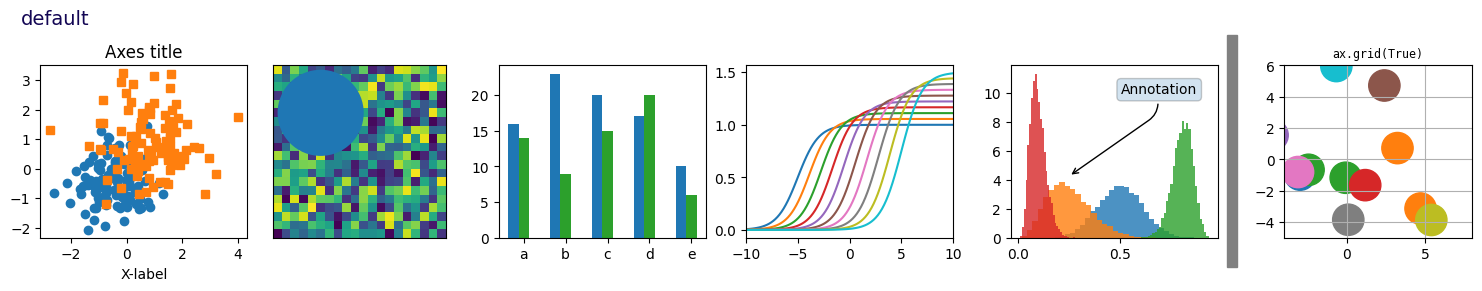

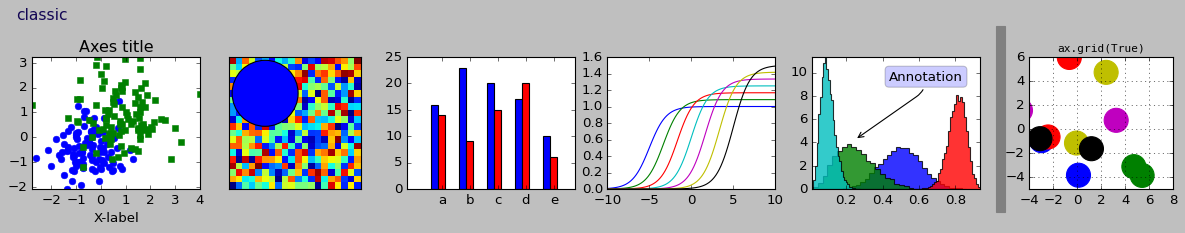

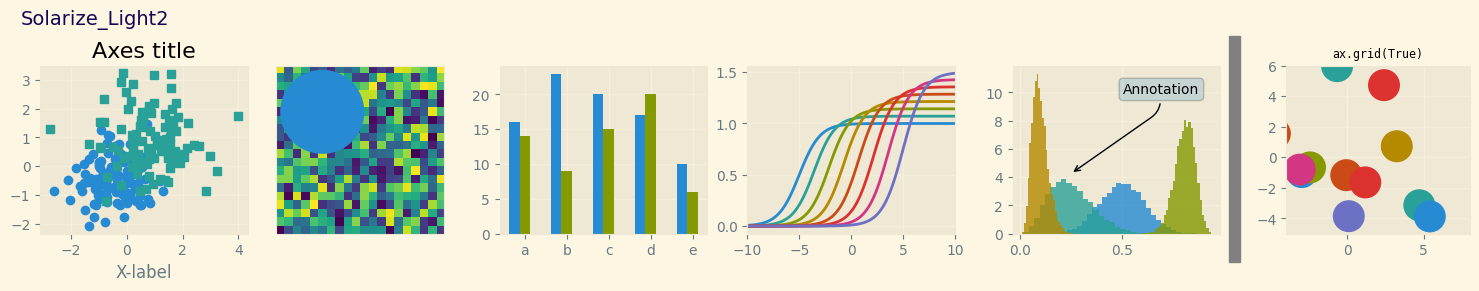

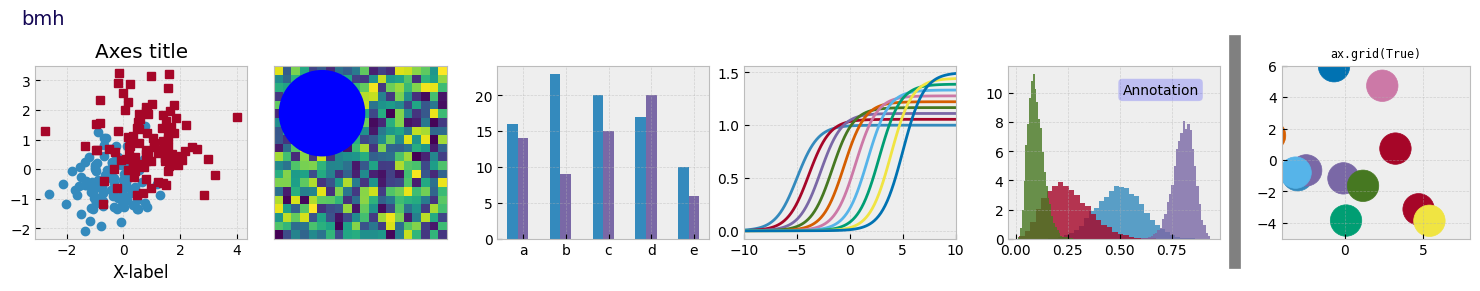

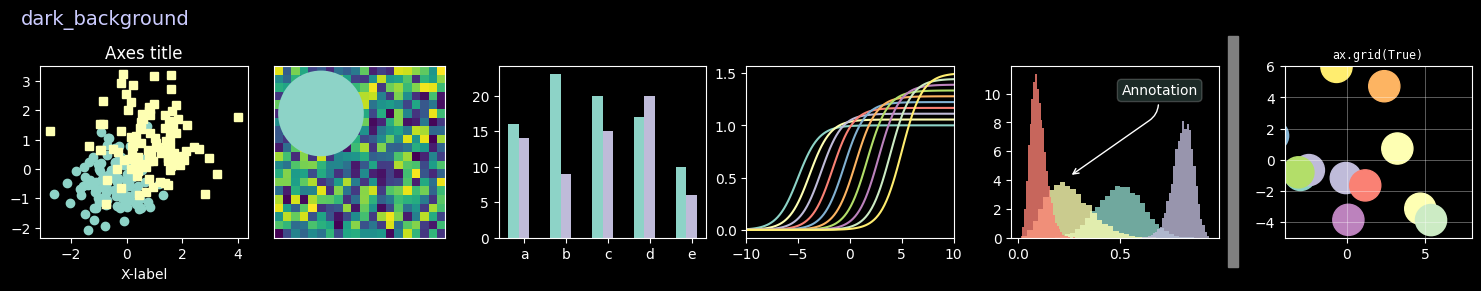

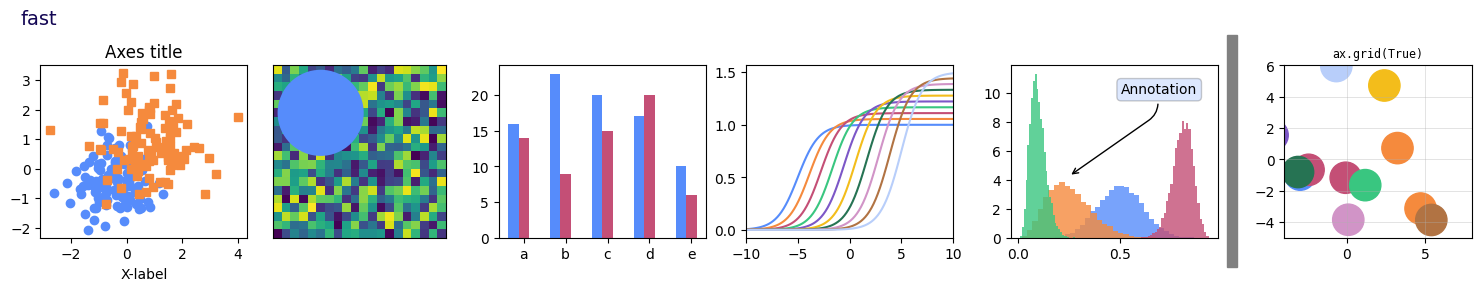

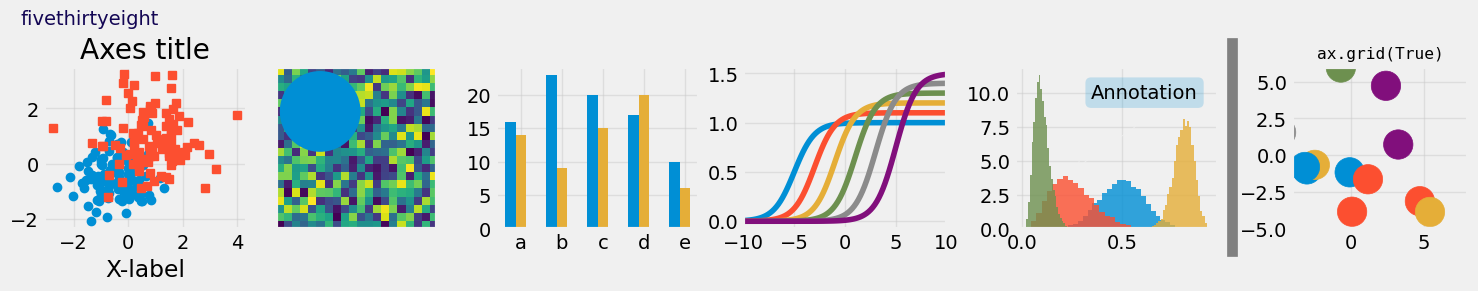

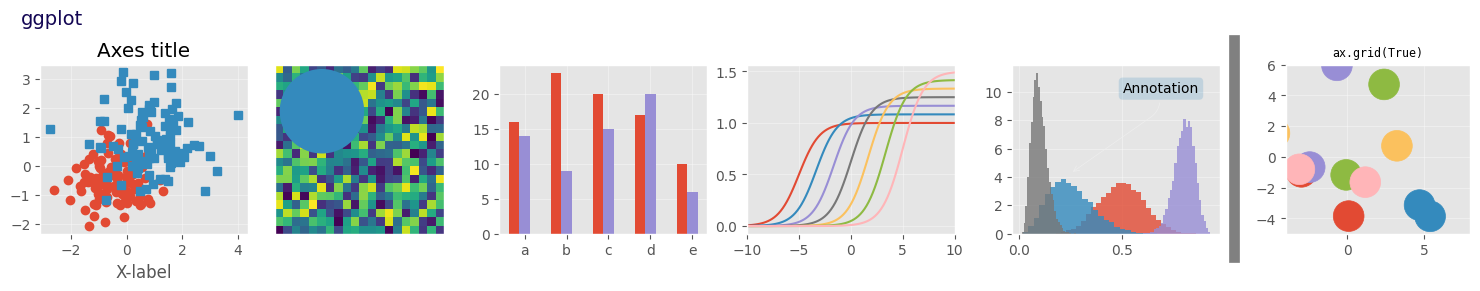

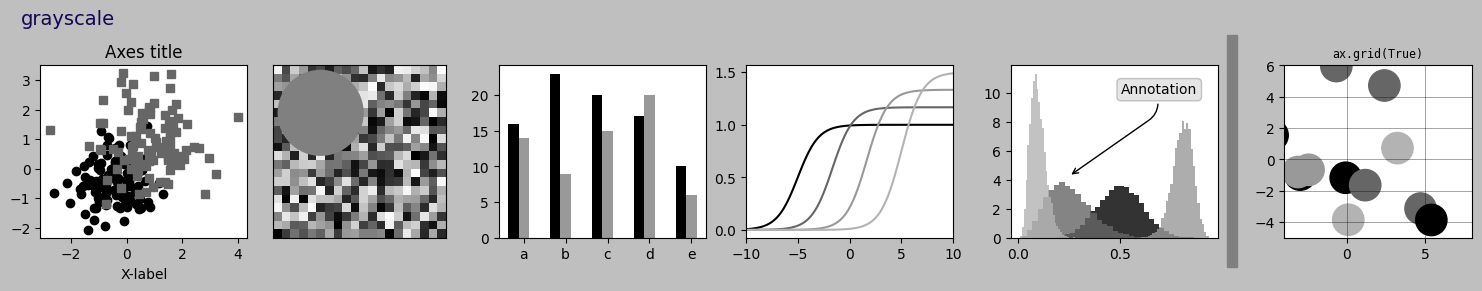

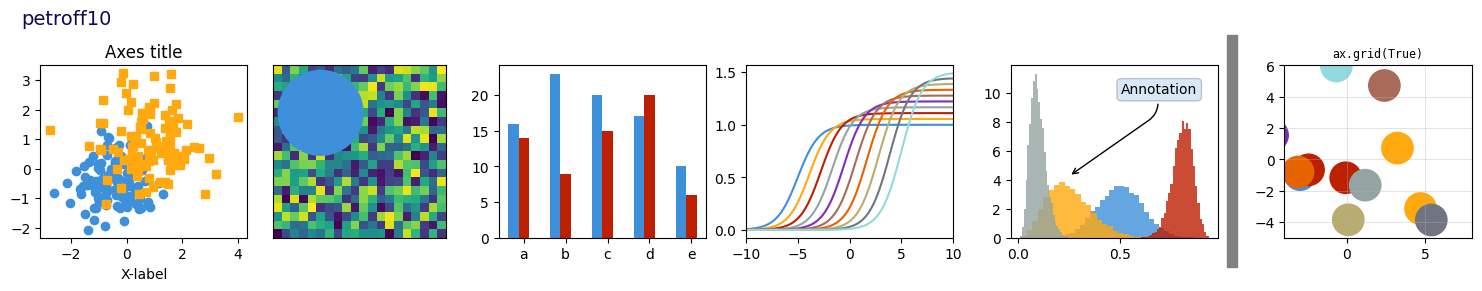

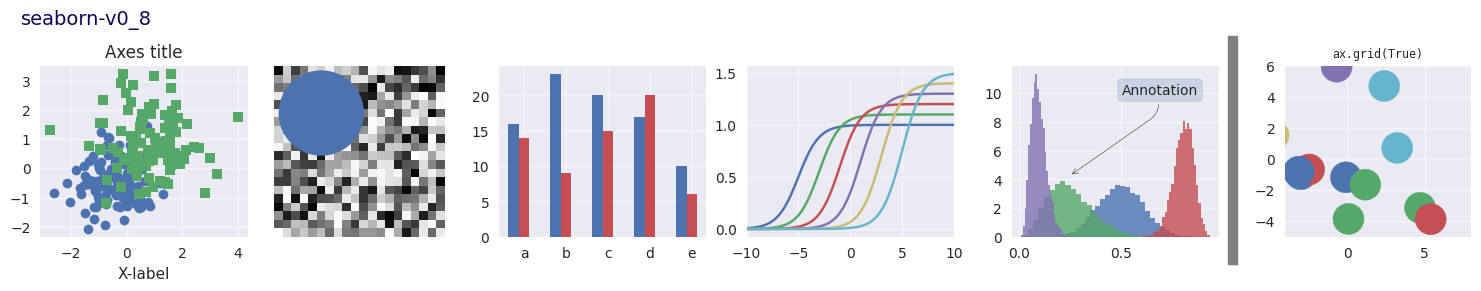

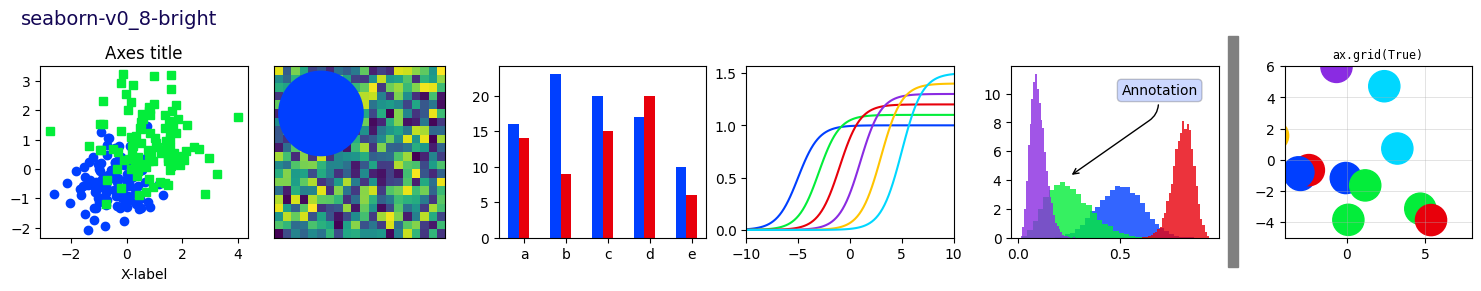

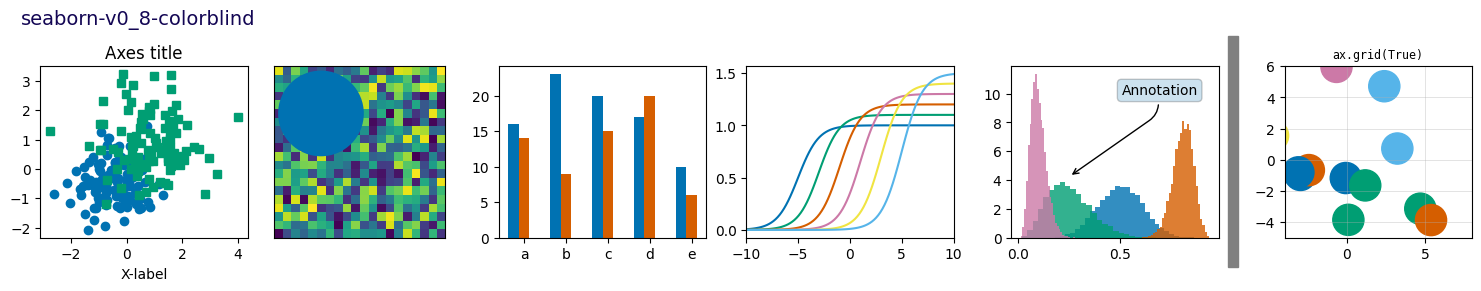

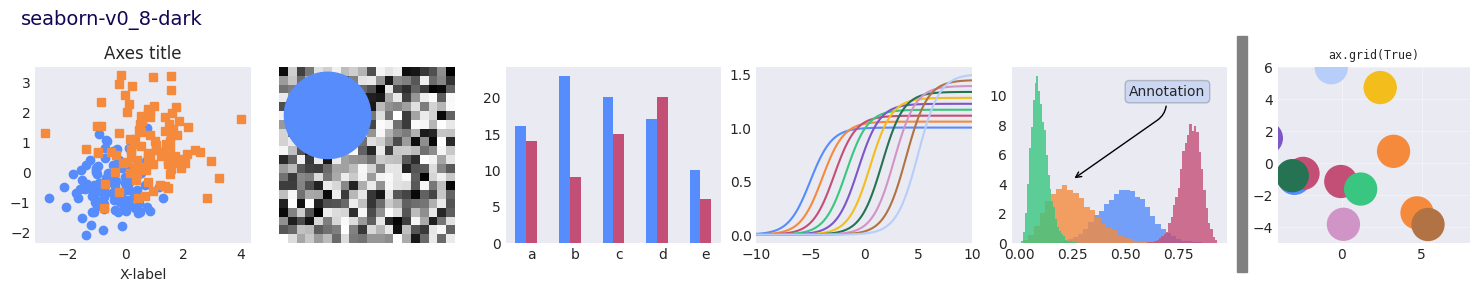

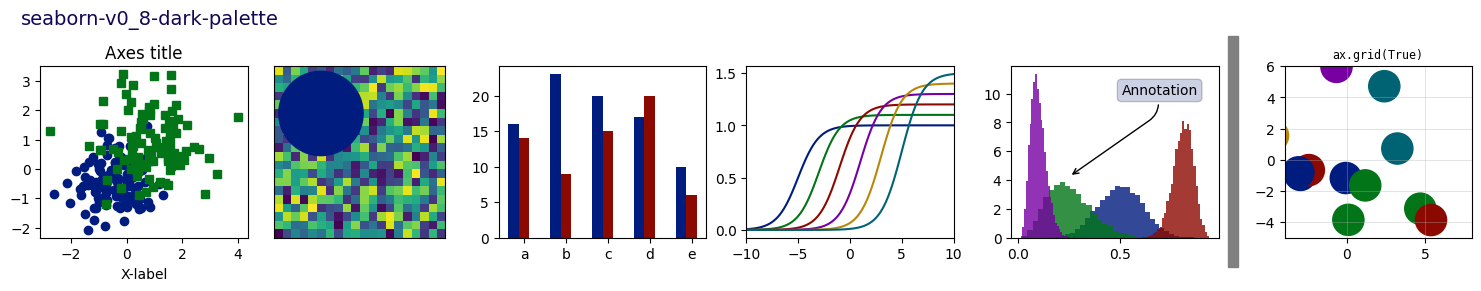

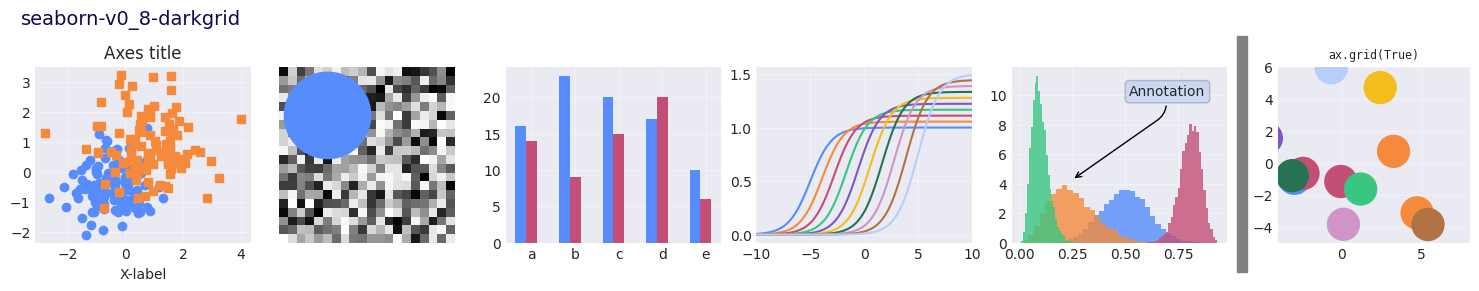

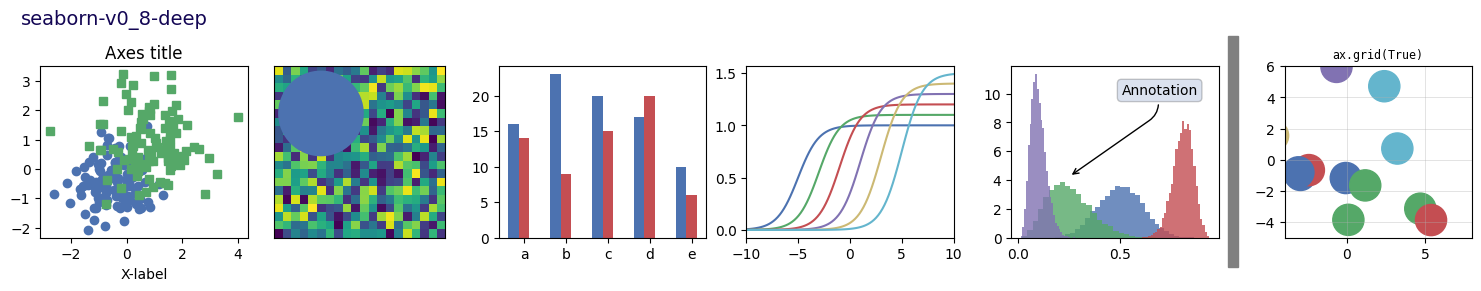

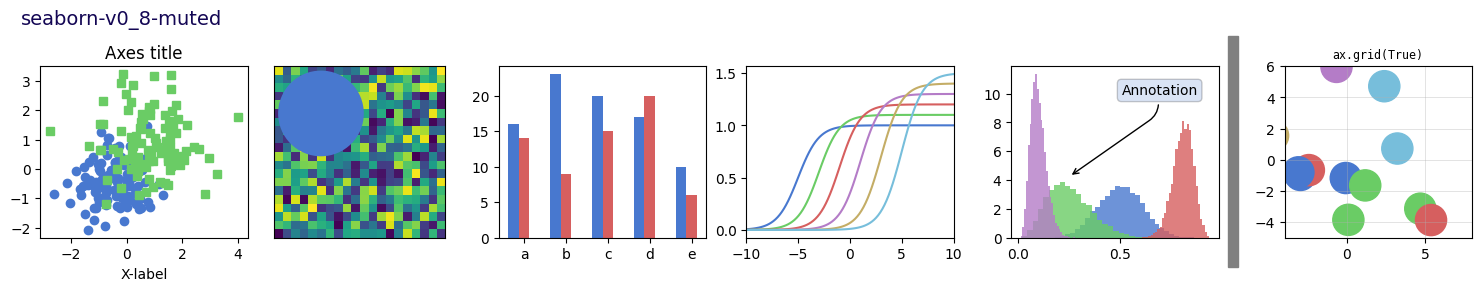

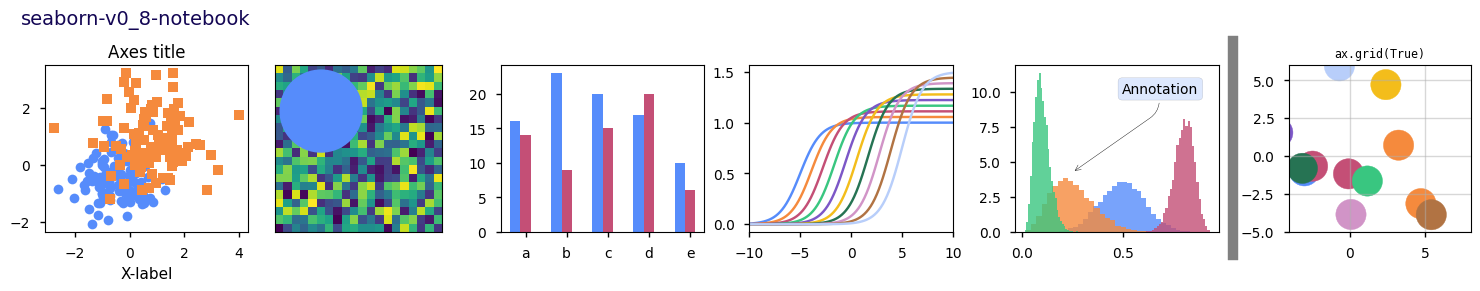

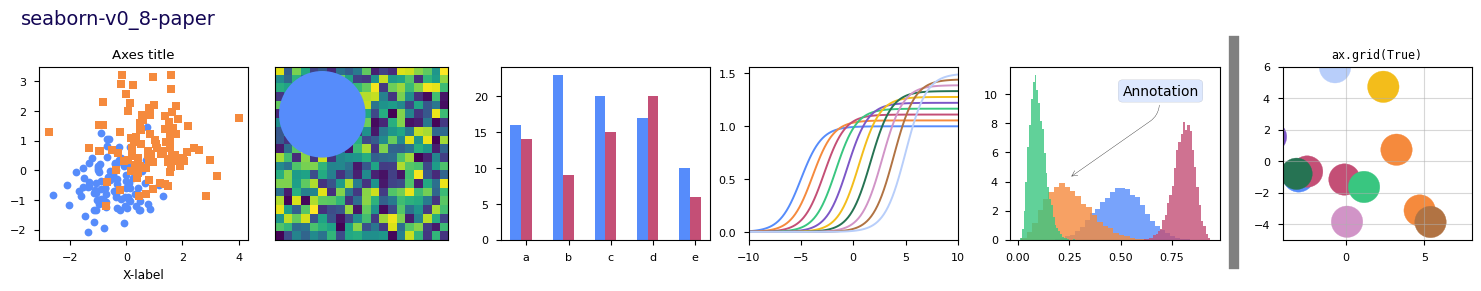

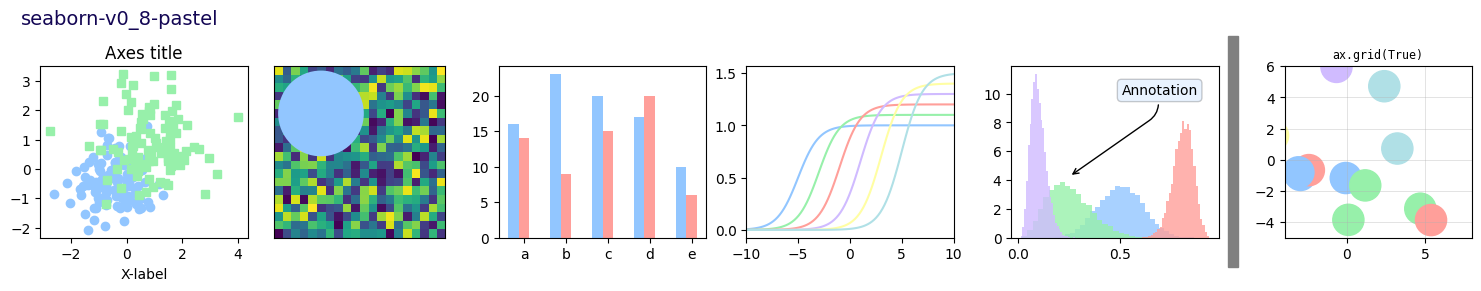

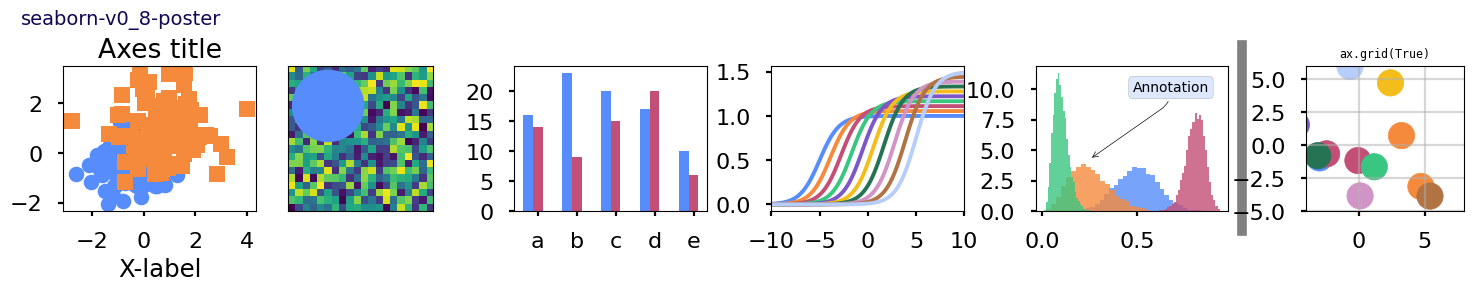

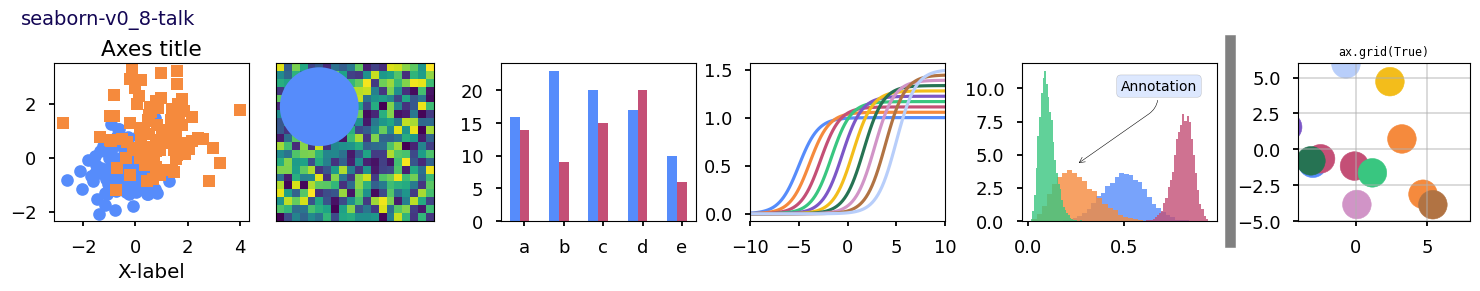

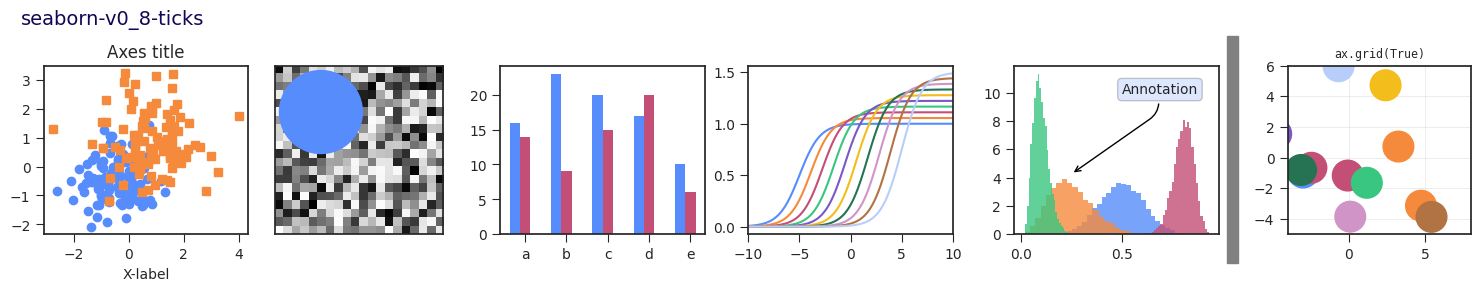

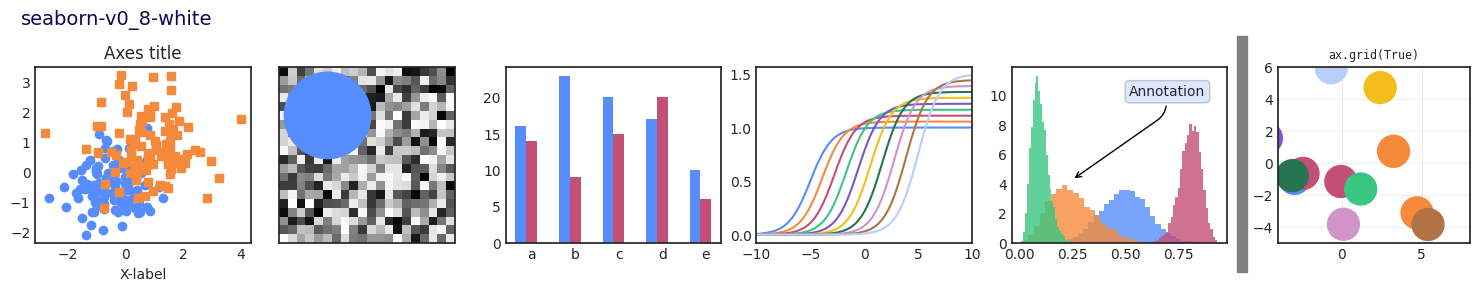

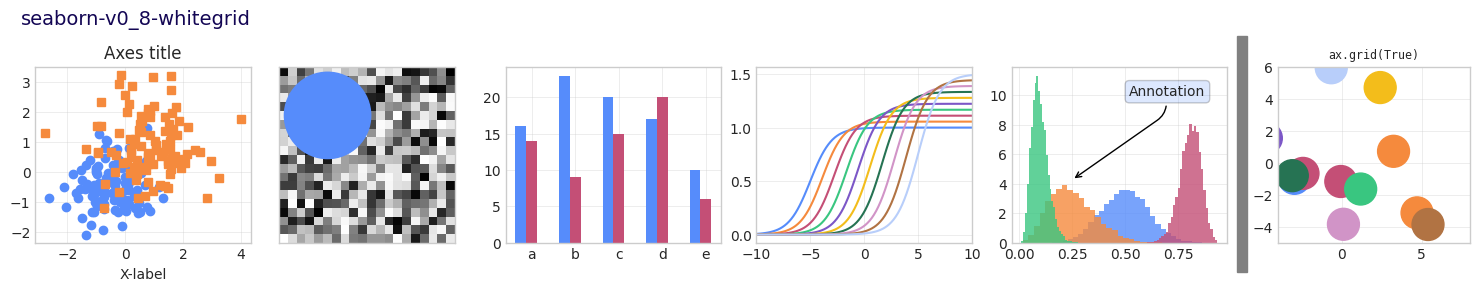

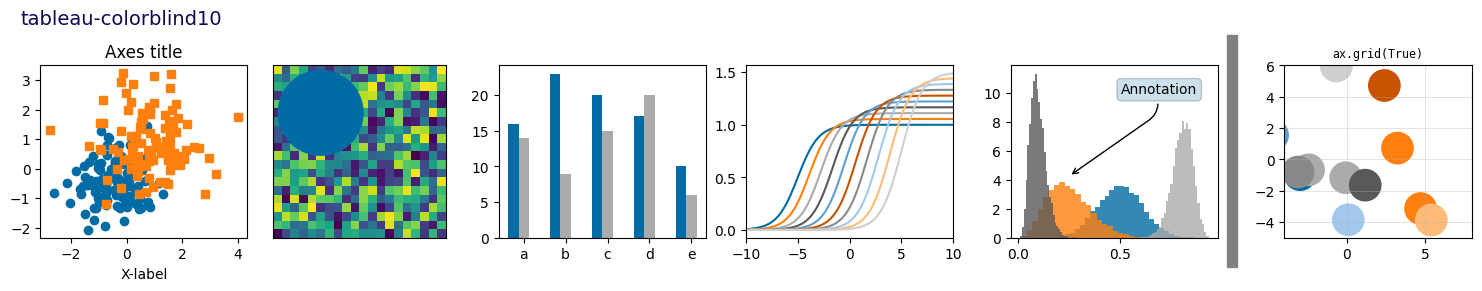

In [16]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

# Fixing random state for reproducibility
np.random.seed(19680801)


def plot_scatter(ax, prng, nb_samples=100):
    """Scatter plot."""
    for mu, sigma, marker in [(-.5, 0.75, 'o'), (0.75, 1., 's')]:
        x, y = prng.normal(loc=mu, scale=sigma, size=(2, nb_samples))
        ax.plot(x, y, ls='none', marker=marker)
    ax.set_xlabel('X-label')
    ax.set_title('Axes title')
    return ax


def plot_colored_lines(ax):
    """Plot lines with colors following the style color cycle."""
    t = np.linspace(-10, 10, 100)

    def sigmoid(t, t0):
        return 1 / (1 + np.exp(-(t - t0)))

    nb_colors = len(plt.rcParams['axes.prop_cycle'])
    shifts = np.linspace(-5, 5, nb_colors)
    amplitudes = np.linspace(1, 1.5, nb_colors)
    for t0, a in zip(shifts, amplitudes):
        ax.plot(t, a * sigmoid(t, t0), '-')
    ax.set_xlim(-10, 10)
    return ax


def plot_bar_graphs(ax, prng, min_value=5, max_value=25, nb_samples=5):
    """Plot two bar graphs side by side, with letters as x-tick labels."""
    x = np.arange(nb_samples)
    ya, yb = prng.randint(min_value, max_value, size=(2, nb_samples))
    width = 0.25
    ax.bar(x, ya, width)
    ax.bar(x + width, yb, width, color='C2')
    ax.set_xticks(x + width, labels=['a', 'b', 'c', 'd', 'e'])
    return ax


def plot_colored_circles(ax, prng, nb_samples=15):
    """
    Plot circle patches.

    NB: draws a fixed amount of samples, rather than using the length of
    the color cycle, because different styles may have different numbers
    of colors.
    """
    for sty_dict, j in zip(plt.rcParams['axes.prop_cycle'](),
                           range(nb_samples)):
        ax.add_patch(plt.Circle(prng.normal(scale=3, size=2),
                                radius=1.0, color=sty_dict['color']))
    ax.grid(visible=True)

    # Add title for enabling grid
    plt.title('ax.grid(True)', family='monospace', fontsize='small')

    ax.set_xlim([-4, 8])
    ax.set_ylim([-5, 6])
    ax.set_aspect('equal', adjustable='box')  # to plot circles as circles
    return ax


def plot_image_and_patch(ax, prng, size=(20, 20)):
    """Plot an image with random values and superimpose a circular patch."""
    values = prng.random_sample(size=size)
    ax.imshow(values, interpolation='none')
    c = plt.Circle((5, 5), radius=5, label='patch')
    ax.add_patch(c)
    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])


def plot_histograms(ax, prng, nb_samples=10000):
    """Plot 4 histograms and a text annotation."""
    params = ((10, 10), (4, 12), (50, 12), (6, 55))
    for a, b in params:
        values = prng.beta(a, b, size=nb_samples)
        ax.hist(values, histtype="stepfilled", bins=30,
                alpha=0.8, density=True)

    # Add a small annotation.
    ax.annotate('Annotation', xy=(0.25, 4.25),
                xytext=(0.9, 0.9), textcoords=ax.transAxes,
                va="top", ha="right",
                bbox=dict(boxstyle="round", alpha=0.2),
                arrowprops=dict(
                          arrowstyle="->",
                          connectionstyle="angle,angleA=-95,angleB=35,rad=10"),
                )
    return ax


def plot_figure(style_label=""):
    """Setup and plot the demonstration figure with a given style."""
    # Use a dedicated RandomState instance to draw the same "random" values
    # across the different figures.
    prng = np.random.RandomState(96917002)

    fig, axs = plt.subplots(ncols=6, nrows=1, num=style_label,
                            figsize=(14.8, 2.8), layout='constrained')

    # make a suptitle, in the same style for all subfigures,
    # except those with dark backgrounds, which get a lighter color:
    background_color = mcolors.rgb_to_hsv(
        mcolors.to_rgb(plt.rcParams['figure.facecolor']))[2]
    if background_color < 0.5:
        title_color = [0.8, 0.8, 1]
    else:
        title_color = np.array([19, 6, 84]) / 256
    fig.suptitle(style_label, x=0.01, ha='left', color=title_color,
                 fontsize=14, fontfamily='DejaVu Sans', fontweight='normal')

    plot_scatter(axs[0], prng)
    plot_image_and_patch(axs[1], prng)
    plot_bar_graphs(axs[2], prng)
    plot_colored_lines(axs[3])
    plot_histograms(axs[4], prng)
    plot_colored_circles(axs[5], prng)

    # add divider
    rec = Rectangle((1 + 0.025, -2), 0.05, 16,
                    clip_on=False, color='gray')

    axs[4].add_artist(rec)

if __name__ == "__main__":

    # Set up a list of all available styles, in alphabetical order but
    # the `default` and `classic` ones, which will be forced resp. in
    # first and second position.
    # styles with leading underscores are for internal use such as testing
    # and plot types gallery. These are excluded here.
    style_list = ['default', 'classic'] + sorted(
        style for style in plt.style.available
        if style != 'classic' and not style.startswith('_'))

    # Plot a demonstration figure for every available style sheet.
    for style_label in style_list:
        with plt.rc_context({"figure.max_open_warning": len(style_list)}):
            with plt.style.context(style_label):
                plot_figure(style_label=style_label)

    plt.show()